# Day 3 — Bias-Variance & Diagnosing Model Fit

## Is our model learning the pattern, or memorizing the data?

A model can fail in two opposite ways.

It may be too simple to capture the patterns in the data, which leads
to underfitting. Or, it may become too complex and memorize the
training examples, which leads to overfitting.

Today, we will deliberately create both situations and use the gap
between training and validation performance to diagnose them.

We will then investigate how reducing model complexity and applying
regularization can improve generalization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

## What data are we working with?

To keep our experiments consistent with the previous days, we will
continue using the Titanic dataset and predict the `Survived` target.

Using the same dataset allows us to focus on model behavior rather
than introducing a new data problem.

In [2]:
df = pd.read_csv("../../Week 1/tested.csv")

numeric_df = df.select_dtypes(include=["number"])

X = numeric_df.drop("Survived", axis=1)
y = numeric_df["Survived"]

X = X.fillna(X.mean())

print("Features:", X.shape)
print("Target:", y.shape)

Features: (418, 6)
Target: (418,)


## How will we measure generalization?

We will separate the data into training, validation, and test sets.
For today's experiments, we will focus on the training and validation
scores.

The test set will remain untouched because it is reserved for the
final evaluation.

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

## Can a very complex tree memorize the training data?

A decision tree with no restriction on its depth can continue splitting
until it creates very specific rules for the training observations.

This may produce an excellent training score, but the important question
is whether the same performance appears on unseen validation data.

In [4]:
deep_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

deep_tree.fit(X_train, y_train)

train_predictions = deep_tree.predict(X_train)
val_predictions = deep_tree.predict(X_val)

train_f1 = f1_score(y_train, train_predictions)
val_f1 = f1_score(y_val, val_predictions)

print("Training F1:", train_f1)
print("Validation F1:", val_f1)
print("Gap:", train_f1 - val_f1)

Training F1: 1.0
Validation F1: 0.45614035087719296
Gap: 0.543859649122807


## What does the training-validation gap tell us?

The decision tree achieved a perfect training F1-score of 1.00, but its
validation F1-score dropped to approximately 0.456.

This creates a large train-validation gap of approximately 0.544.

The high training score combined with the much lower validation score is
a strong sign of overfitting. The unrestricted tree has become too complex
and has learned patterns that are specific to the training data rather
than patterns that generalize well to unseen observations.

This confirms why training performance alone is not enough to judge a
machine learning model.

## What happens when the model is too simple?

If an unrestricted tree can become too complex, what happens when we
restrict the tree too much?

We will use a decision tree with a maximum depth of only 1. Such a
simple model has very limited capacity to learn relationships in the data.

In [5]:
simple_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

simple_tree.fit(X_train, y_train)

simple_train_predictions = simple_tree.predict(X_train)
simple_val_predictions = simple_tree.predict(X_val)

simple_train_f1 = f1_score(y_train, simple_train_predictions)
simple_val_f1 = f1_score(y_val, simple_val_predictions)

print("Training F1:", simple_train_f1)
print("Validation F1:", simple_val_f1)
print("Gap:", simple_train_f1 - simple_val_f1)

Training F1: 0.586046511627907
Validation F1: 0.40625
Gap: 0.179796511627907


## What happens when the model is too simple?

The shallow decision tree achieved a training F1-score of approximately
0.586 and a validation F1-score of approximately 0.406.

Unlike the deep tree, the training score is not extremely high. The model
also performs relatively poorly on the validation data.

This suggests that the tree is too simple to capture the relationships
in the dataset, which is consistent with underfitting.

The train-validation gap is also much smaller than the gap observed with
the unrestricted tree. However, a small gap alone does not guarantee a
good model: both scores must also be sufficiently high.

## How clearly can we see the difference between the two models?

The numerical results show different types of model behavior.
Visualizing the training and validation F1-scores makes the difference
easier to interpret.

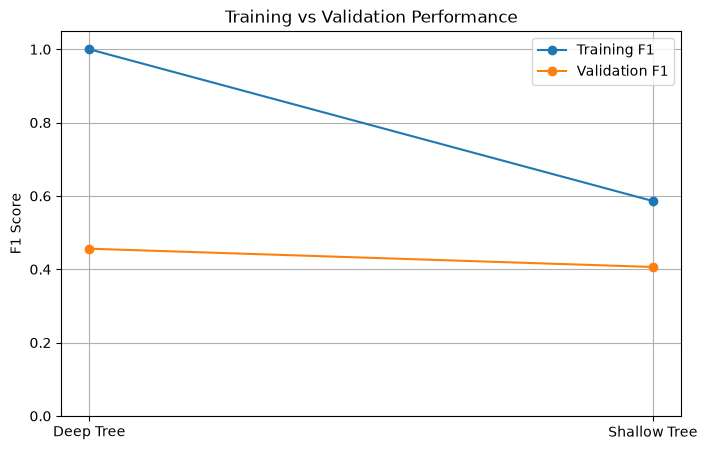

In [6]:
models = ["Deep Tree", "Shallow Tree"]

train_scores = [train_f1, simple_train_f1]
val_scores = [val_f1, simple_val_f1]

x = range(len(models))

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    train_scores,
    marker="o",
    label="Training F1"
)

plt.plot(
    x,
    val_scores,
    marker="o",
    label="Validation F1"
)

plt.xticks(x, models)
plt.ylabel("F1 Score")
plt.title("Training vs Validation Performance")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)

plt.show()

## Can we reduce overfitting without making the model too simple?

The unrestricted tree clearly overfits, while the depth-1 tree is too
simple.

Instead of choosing one extreme, we will test several intermediate
tree depths and compare their training and validation F1-scores.

The goal is to find a model that achieves strong validation performance
while keeping the training-validation gap reasonably small.

In [7]:
depths = [2, 3, 4, 5, 6, 8, 10]

train_scores = []
val_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    val_pred = tree.predict(X_val)

    train_scores.append(f1_score(y_train, train_pred))
    val_scores.append(f1_score(y_val, val_pred))

results = pd.DataFrame({
    "Max Depth": depths,
    "Training F1": train_scores,
    "Validation F1": val_scores
})

results["Gap"] = results["Training F1"] - results["Validation F1"]

results

,Max Depth,Training F1,Validation F1,Gap
0,2,0.156863,0.129032,0.027830
1,3,0.593407,0.333333,0.260073
2,4,0.451613,0.216216,0.235397
3,5,0.585714,0.382979,0.202736
4,6,0.723926,0.326531,0.397396
5,8,0.845238,0.352941,0.492297
6,10,0.939227,0.444444,0.494782


## How does model complexity affect performance?

As tree depth increases, the model becomes more complex.

We expect training performance to improve as the tree gains more
capacity. However, after a certain point, validation performance may
stop improving or decrease because the model begins to overfit.

This experiment helps us visualize the bias-variance trade-off.

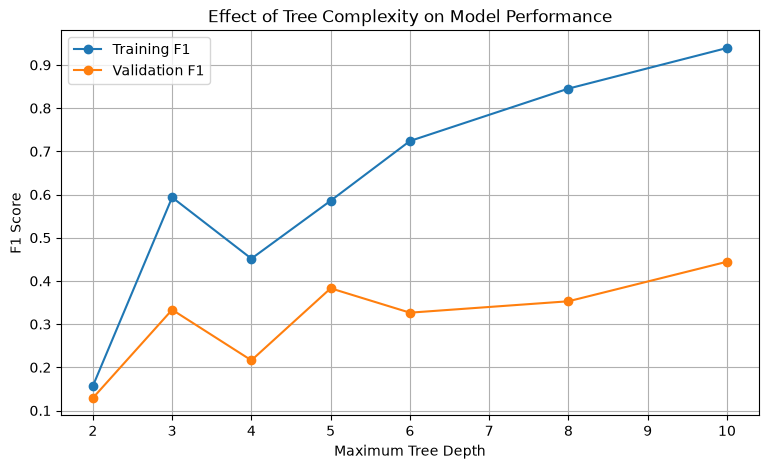

In [8]:
plt.figure(figsize=(9, 5))

plt.plot(
    results["Max Depth"],
    results["Training F1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    results["Max Depth"],
    results["Validation F1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("F1 Score")
plt.title("Effect of Tree Complexity on Model Performance")
plt.legend()
plt.grid(True)

plt.show()

## What does model complexity reveal?

The results demonstrate the bias-variance trade-off in practice.

As the tree becomes deeper, its training performance generally increases.
However, the validation performance does not improve at the same rate.

At depth 10, the model achieves the highest validation F1-score among the
tested depths (0.444), but its training-validation gap is approximately
0.495, indicating a strong tendency toward overfitting.

A depth of 5 provides a smaller gap of approximately 0.203 while still
achieving a validation F1-score of 0.383.

This shows that choosing a model is not simply about maximizing the
training score. We need to balance predictive performance with the
ability to generalize to unseen data.

## How can regularization control model complexity?

Regularization is another way to reduce overfitting by penalizing model
complexity.

For linear regression, two common approaches are Ridge (L2) and Lasso (L1).

Ridge shrinks coefficients toward zero, while Lasso can shrink some
coefficients exactly to zero, which can also perform feature selection.

The strength of regularization is controlled by the `alpha` parameter.
A larger alpha applies a stronger penalty and produces a simpler model.

In [9]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
housing = fetch_california_housing(as_frame=True)

X_reg = housing.data
y_reg = housing.target

X_reg.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [12]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_reg_train, y_reg_train)

ridge_predictions = ridge.predict(X_reg_test)

ridge_rmse = mean_squared_error(
    y_reg_test,
    ridge_predictions
) ** 0.5

ridge_r2 = r2_score(
    y_reg_test,
    ridge_predictions
)

print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge RMSE: 0.7455222779992702
Ridge R²: 0.5758549611440126


In [13]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_reg_train, y_reg_train)

lasso_predictions = lasso.predict(X_reg_test)

lasso_rmse = mean_squared_error(
    y_reg_test,
    lasso_predictions
) ** 0.5

lasso_r2 = r2_score(
    y_reg_test,
    lasso_predictions
)

print("Lasso RMSE:", lasso_rmse)
print("Lasso R²:", lasso_r2)

Lasso RMSE: 0.7832697618354822
Lasso R²: 0.5318167610318159


## Ridge vs. Lasso: What did we observe?

Ridge achieved an RMSE of approximately 0.746 and an R² of 0.576,
while Lasso achieved an RMSE of approximately 0.783 and an R² of 0.532.

Since lower RMSE indicates smaller prediction errors and higher R²
indicates that more variance is explained by the model, Ridge performed
better in this experiment.

This does not mean Ridge is always better than Lasso. The result depends
on the dataset, the features, and the regularization strength (`alpha`).

The important idea is that regularization gives us a way to control model
complexity and reduce the risk of overfitting.

# Final Takeaway

Today we diagnosed model fit instead of looking only at a model's final
score.

The unrestricted Decision Tree achieved a perfect training F1-score of
1.00 but only 0.456 on validation data, demonstrating clear overfitting.

When the tree was restricted to a depth of 1, both training and
validation performance were relatively low, showing behavior consistent
with underfitting.

Testing different tree depths demonstrated the bias-variance trade-off:
increasing complexity improved training performance, but eventually
created a much larger gap between training and validation performance.

We also explored regularization using Ridge and Lasso. In our regression
experiment, Ridge achieved better performance than Lasso, although the
choice between them depends on the dataset and problem.

The main lesson is that good machine learning is not about making a model
as complex as possible. The goal is to find a level of complexity that
captures useful patterns while still generalizing to unseen data.